# Векторизированные вычислениям на NumPy

## ИУ5 ОАД

### Цель лабораторной работы:
Изучение и применение векторизированных вычислений с использованием библиотеки NumPy для эффективной обработки массивов данных в языке программирования Python.

### Задачи:

> Изучение основных принципов векторизированных вычислений и преимуществ использования библиотеки NumPy.

> Освоение основных функций NumPy для работы с многомерными массивами.

> Решение задач, требующих обработки данных в векторизированной форме.

> Сравнение производительности векторизированных вычислений с обычными циклами в Python.

## Задание

#### 1. Подсчитать произведение ненулевых элементов на диагонали прямоугольной матрицы. 
Для X = np.array([[1, 0, 1], [2, 0, 2], [3, 0, 3], [4, 4, 4]]) 

#### 2. Дана матрица X и два вектора одинаковой длины i и j. Построить вектор np.array([X[i[0], j[0]], X[i[1], j[1]], ... , X[i[N-1], j[N-1]]]).

#### 3. Даны два вектора x и y. Проверить, задают ли они одно и то же мультимножество. 
Для x = np.array([1, 2, 2, 4]), y = np.array([4, 2, 1, 2]) 

#### 4. Найти максимальный элемент в векторе x среди элементов, перед которыми стоит нулевой. 
Для x = np.array([6, 2, 0, 3, 0, 0, 5, 7, 0]) 

#### 5. Дан трёхмерный массив, содержащий изображение, размера (height, width, numChannels), а также вектор длины numChannels. Сложить каналы изображения с указанными весами, и вернуть результат в виде матрицы размера (height, width). Считать реальное изображение можно при помощи функции scipy.misc.imread (если изображение не в формате png, установите пакет pillow: conda install pillow). Преобразуйте цветное изображение в оттенки серого, использовав коэффициенты np.array([0.299, 0.587, 0.114]).

#### 6. Реализовать кодирование длин серий (Run-length encoding). Дан вектор x. Необходимо вернуть кортеж из двух векторов одинаковой длины. Первый содержит числа, а второй - сколько раз их нужно повторить. 
Пример: x = np.array([2, 2, 2, 3, 3, 3, 5, 2, 2]). 

#### 7. Даны две выборки объектов - X и Y. Вычислить матрицу евклидовых расстояний между объектами. Сравнить с функцией scipy.spatial.distance.cdist.

##### Замечание. Можно считать, что все указанные объекты непустые (к примеру, в задаче №1 на диагонали матрицы есть ненулевые элементы).
Полезные функции NumPy: np.zeros, np.ones, np.diag, np.eye, np.arange, np.linspace, np.meshgrid,
np.random.random, np.random.randint, np.shape, np.reshape, np.transpose, np.any, np.all, np.nonzero, np.where,
np.sum, np.cumsum, np.prod, np.diff, np.min, np.max, np.minimum, np.maximum, np.argmin, np.argmax, np.unique,
np.sort, np.argsort, np.bincount, np.ravel, np.newaxis, np.dot, np.linalg.inv, np.linalg.solve.
Многие из этих функций можно использовать так: x.argmin().

##### Ссылки на документацю numpy:

> https://numpy.org/devdocs

> https://numpy.org/devdocs/user/quickstart.html

## Для каждой из задач:
(a) Написать на Python + NumPy несколько вариантов кода различной эффективности. Должно быть не
менее трёх вариантов, в том числе как минимум один полностью векторизованный вариант (без циклов), и один
вариант без векторизации (с циклами). Третий вариант решения — на ваше усмотрение, например, это может быть
наиболее хорошо читаемый способ решения, или частично векторизованный вариант. Все пункты выполнять в одном google collab/jupyter notebook (локально), разделяя их пунктами 1., 1.1, 1.2, 1.3; 2., 2.1, 2.2, 2.3; и тд.

(b) Сравнить в IPython Notebook при помощи %timeit скорость работы на нескольких тестовых наборах
РАЗНОГО размера (минимум 3, причём отличаться размеры входных данных должны минимум на порядок. Например, массивы длины 100, 1000, 10000).

(c) Проанализировать полученные данные о скорости работы разных реализаций.

(d) Получить выводы.

In [1]:
# раскомментировать если не установлен numpy 
# !pip install numpy

In [3]:
import numpy as np

In [24]:
# 1.1 Векторизованный вариант (без циклов)
def n11(matrix):
    diagonal = np.diag(matrix)
    non_zero_elements = diagonal[diagonal != 0]
    if len(non_zero_elements) == 0:
        return 0
    return np.prod(non_zero_elements)

# 1.2 Вариант с циклами (без векторизации)
def n12(matrix):
    product = 1
    found_non_zero = False
    
    for i in range(min(matrix.shape[0], matrix.shape[1])):
        el = matrix[i, i]
        if el != 0:
            product *= el
            found_non_zero = True
    
    return product if found_non_zero else 0


def n13(matrix):
    diag = [matrix[i][i] for i in range(min(matrix.shape[0], matrix.shape[1])) if matrix[i][i] != 0]
    return np.prod(diag) if len(diag) > 0 else 0


x = np.array([[1, 0, 1], [2, 0, 2], [3, 0, 3], [4, 4, 4]])
print(n11(x) == n12(x) == n13(x))

small_matrix = np.random.randint(0, 10, size=(100, 100))
medium_matrix = np.random.randint(0, 10, size=(1000, 1000))
large_matrix = np.random.randint(0, 10, size=(10000, 10000))

print("\n1. МАЛЕНЬКАЯ МАТРИЦА (100x100):")
print("Векторизованная версия (n11):")
%timeit n11(small_matrix)

print("Версия с циклами (n12):")
%timeit n12(small_matrix)

print("Версия с list comprehension (n13):")
%timeit n13(small_matrix)

print("\n2. СРЕДНЯЯ МАТРИЦА (1000x1000):")
print("Векторизованная версия (n11):")
%timeit n11(medium_matrix)

print("Версия с циклами (n12):")
%timeit n12(medium_matrix)

print("Версия с list comprehension (n13):")
%timeit n13(medium_matrix)

print("\n3. БОЛЬШАЯ МАТРИЦА (10000x10000):")
print("Векторизованная версия (n11):")
%timeit n11(large_matrix)

print("Версия с циклами (n12):")
%timeit n12(large_matrix)

print("Версия с list comprehension (n13):")
%timeit n13(large_matrix)

True

1. МАЛЕНЬКАЯ МАТРИЦА (100x100):
Векторизованная версия (n11):
2.88 μs ± 8.86 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
Версия с циклами (n12):


/var/folders/wq/tf0mhtq56yn2f2vpbxk2jfpr0000gn/T/ipykernel_5827/2103249968.py:17: RuntimeWarning: overflow encountered in scalar multiply
  product *= el


23.7 μs ± 404 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
Версия с list comprehension (n13):
24.9 μs ± 177 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)

2. СРЕДНЯЯ МАТРИЦА (1000x1000):
Векторизованная версия (n11):
4.95 μs ± 15.1 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
Версия с циклами (n12):
132 μs ± 3.78 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
Версия с list comprehension (n13):
238 μs ± 1.74 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)

3. БОЛЬШАЯ МАТРИЦА (10000x10000):
Векторизованная версия (n11):
56.2 μs ± 237 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
Версия с циклами (n12):
1.19 ms ± 44.9 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
Версия с list comprehension (n13):
2.39 ms ± 6.01 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [42]:
# 2.1 Полностью векторизованный вариант
def n21(X, i, j):
    return X[i, j]

# 2.2 Вариант с циклами
def n22(X, i, j):
    n = len(i)
    result = np.zeros(n, dtype=X.dtype)
    for idx in range(n):
        result[idx] = X[i[idx], j[idx]]
    return result

# 2.3 Частично векторизованный вариант
def n23(X, i, j):
    return np.array([X[i_val, j_val] for i_val, j_val in zip(i, j)])

X = np.array([[1, 2, 3],
              [4, 5, 6],
              [7, 8, 9]])
i = np.array([0, 1, 2])
j = np.array([1, 2, 0])

print(all(np.equal(n21(X, i, j), n22(X, i, j))) and all(np.equal(n23(X, i, j), n22(X, i, j))))

small_X = np.random.randint(0, 100, size=(100, 100))
small_i = np.random.randint(0, 100, size=100)
small_j = np.random.randint(0, 100, size=100)

# Средний набор
medium_X = np.random.randint(0, 100, size=(1000, 1000))
medium_i = np.random.randint(0, 1000, size=1000)
medium_j = np.random.randint(0, 1000, size=1000)

# Большой набор
large_X = np.random.randint(0, 100, size=(10000, 10000))
large_i = np.random.randint(0, 10000, size=10000)
large_j = np.random.randint(0, 10000, size=10000)

print("\n1. МАЛЕНЬКИЙ НАБОР (матрица 100x100, 100 индексов):")
print("Полностью векторизованная версия (n21):")
%timeit n21(small_X, small_i, small_j)

print("Версия с циклами (n22):")
%timeit n22(small_X, small_i, small_j)

print("Частично векторизованная версия (n23):")
%timeit n23(small_X, small_i, small_j)

print("\n2. СРЕДНИЙ НАБОР (матрица 1000x1000, 1000 индексов):")
print("Полностью векторизованная версия (n21):")
%timeit n21(medium_X, medium_i, medium_j)

print("Версия с циклами (n22):")
%timeit n22(medium_X, medium_i, medium_j)

print("Частично векторизованная версия (n23):")
%timeit n23(medium_X, medium_i, medium_j)

print("\n3. БОЛЬШОЙ НАБОР (матрица 10000x10000, 10000 индексов):")
print("Полностью векторизованная версия (n21):")
%timeit n21(large_X, large_i, large_j)

print("Версия с циклами (n22):")
%timeit n22(large_X, large_i, large_j)

print("Частично векторизованная версия (n23):")
%timeit n23(large_X, large_i, large_j)


True

1. МАЛЕНЬКИЙ НАБОР (матрица 100x100, 100 индексов):
Полностью векторизованная версия (n21):
940 ns ± 2.8 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)
Версия с циклами (n22):
19.7 μs ± 102 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
Частично векторизованная версия (n23):
16.7 μs ± 59.6 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)

2. СРЕДНИЙ НАБОР (матрица 1000x1000, 1000 индексов):
Полностью векторизованная версия (n21):
4.35 μs ± 24 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
Версия с циклами (n22):
217 μs ± 983 ns per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
Частично векторизованная версия (n23):
171 μs ± 275 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)

3. БОЛЬШОЙ НАБОР (матрица 10000x10000, 10000 индексов):
Полностью векторизованная версия (n21):
44.4 μs ± 391 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
Версия с циклами (n22):
2.18 ms ± 16.3 μs per loop (mean ± std. d

In [50]:
# 3.1 Полностью векторизованный вариант
def n31(x, y):
    return np.array_equal(np.sort(x), np.sort(y))

# 3.2 Вариант с циклами
def n32(x, y):
    if len(x) != len(y):
        return False
    for val in x:
        found = False
        y_used = set()
        for i in range(len(y)):
            if i not in y_used and y[i] == val:
                found = True
                y_used.add(i)
                break
        if not found:
            return False
    return True

# 3.3 Частично векторизованный вариант
def n33(x, y):
    x = list(x)
    y = list(y)
    x_cnts = {i: x.count(i) for i in set(x)}
    y_cnts = {i: y.count(i) for i in set(y)}
    return x_cnts == y_cnts
    

# Тестирование
x = np.array([1, 2, 2, 4])
y = np.array([4, 2, 1, 2])

print(n31(x, y) == n32(x, y) == n33(x, y))

small_x = np.random.randint(0, 100, size=100)
small_y = np.random.randint(0, 100, size=100)

# Средний набор
medium_x = np.random.randint(0, 100, size=1000)
medium_y = np.random.randint(0, 100, size=1000)

# Большой набор
large_x = np.random.randint(0, 100, size=10000)
large_y = np.random.randint(0, 100, size=10000)

print("Маленький набор (100 элементов):")
print("n31:", end=" ")
%timeit n31(small_x, small_y)
print("n32:", end=" ")
%timeit n32(small_x, small_y)
print("n33:", end=" ")
%timeit n33(small_x, small_y)

print("\nСредний набор (1000 элементов):")
print("n31:", end=" ")
%timeit n31(medium_x, medium_y)
print("n32:", end=" ")
%timeit n32(medium_x, medium_y)
print("n33:", end=" ")
%timeit n33(medium_x, medium_y)

print("\nБольшой набор (10000 элементов):")
print("n31:", end=" ")
%timeit n31(large_x, large_y)
print("n32:", end=" ")
%timeit n32(large_x, large_y)
print("n33:", end=" ")
%timeit n33(large_x, large_y)

True
Маленький набор (100 элементов):
n31: 2.85 μs ± 8.17 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
n32: 6.07 μs ± 31.4 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
n33: 149 μs ± 360 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)

Средний набор (1000 элементов):
n31: 19.6 μs ± 2.31 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
n32: 5.91 ms ± 60.8 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
n33: 2.32 ms ± 12.6 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)

Большой набор (10000 элементов):
n31: 465 μs ± 2.97 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
n32: 63.4 ms ± 196 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
n33: 23.3 ms ± 46.6 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [58]:
# 4.1 Полностью векторизованный вариант
def n41(x):
    mask = (np.roll(x, 1) == 0) & (np.arange(len(x)) > 0)
    return x[mask].max() if np.any(mask) else None

# 4.2 Вариант с циклами
def n42(x):
    max_val = -np.inf
    for i in range(1, len(x)):
        if x[i - 1] == 0:
            if x[i] > max_val:
                max_val = x[i]
    return max_val if max_val != -np.inf else None

# 4.3 Частично векторизованный вариант
def n43(x):
    return max(x[i] for i in range(1, len(x)) if x[i - 1] == 0)

# Маленький набор
small_x = np.random.randint(0, 10, size=100)

# Средний набор
medium_x = np.random.randint(0, 10, size=1000)

# Большой набор
large_x = np.random.randint(0, 10, size=10000)

print("Маленький набор (100 элементов):")
print("n41:", end=" ")
%timeit n41(small_x)
print("n42:", end=" ")
%timeit n42(small_x)
print("n43:", end=" ")
%timeit n43(small_x)

print("\nСредний набор (1000 элементов):")
print("n41:", end=" ")
%timeit n41(medium_x)
print("n42:", end=" ")
%timeit n42(medium_x)
print("n43:", end=" ")
%timeit n43(medium_x)

print("\nБольшой набор (10000 элементов):")
print("n41:", end=" ")
%timeit n41(large_x)
print("n42:", end=" ")
%timeit n42(large_x)
print("n43:", end=" ")
%timeit n43(large_x)

Маленький набор (100 элементов):
n41: 8.26 μs ± 39 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
n42: 8.58 μs ± 51.7 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
n43: 7.66 μs ± 51.9 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)

Средний набор (1000 элементов):
n41: 9.74 μs ± 51.9 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
n42: 82 μs ± 123 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
n43: 85.7 μs ± 567 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)

Большой набор (10000 элементов):
n41: 22.9 μs ± 185 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
n42: 840 μs ± 7.31 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
n43: 867 μs ± 1.78 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


11.9 ms ± 163 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
937 ms ± 2.19 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
2.94 ms ± 230 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


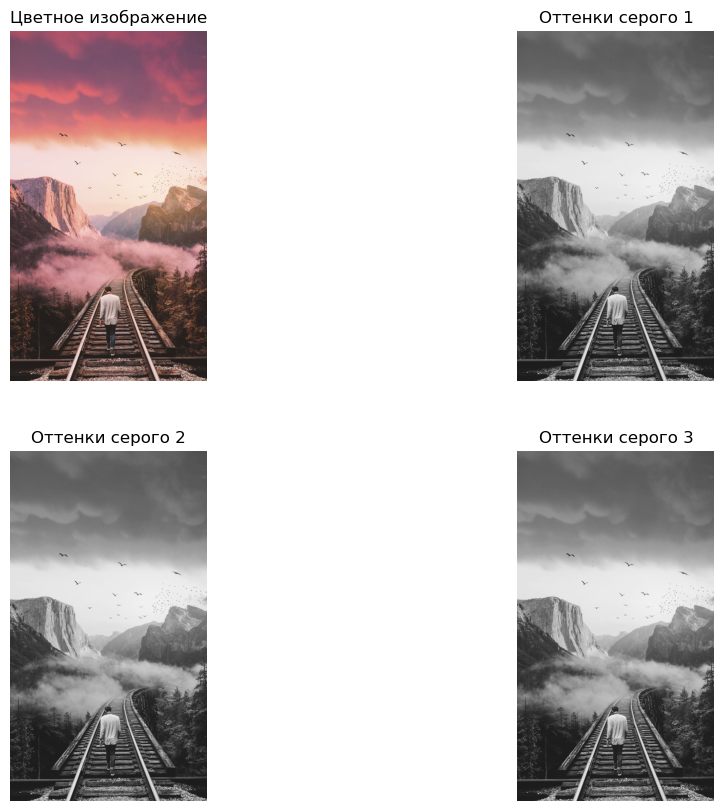

In [36]:
# 5.1 Полностью векторизованный вариант
def n51(image, weights):
    return np.dot(image, weights)

# 5.2 Вариант с циклами
def n52(image, weights):
    height, width, numChannels = image.shape
    result = np.zeros((height, width))
    
    for i in range(height):
        for j in range(width):
            for k in range(numChannels):
                result[i, j] += image[i, j, k] * weights[k]
    
    return result

# 5.3 Частично векторизованный вариант
def n53(image, weights):
    result = np.zeros((image.shape[0], image.shape[1]))
    for k in range(len(weights)):
        result += image[:, :, k] * weights[k]
    return result


from PIL import Image

image = Image.open("pic.jpg")
color_image = np.array(image)
weights = np.array([0.299, 0.587, 0.114])

grayscale_image1 = n51(color_image, weights)
%timeit n51(color_image, weights)
grayscale_image2 = n52(color_image, weights)
%timeit n52(color_image, weights)
grayscale_image3 = n53(color_image, weights)
%timeit n53(color_image, weights)


fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Показываем результат
axes[0, 0].imshow(color_image)
axes[0, 0].set_title('Цветное изображение')
axes[0, 0].axis('off')

# Оттенки серого 1
axes[0, 1].imshow(grayscale_image1, cmap='gray')
axes[0, 1].set_title('Оттенки серого 1')
axes[0, 1].axis('off')

# Оттенки серого 2
axes[1, 0].imshow(grayscale_image2, cmap='gray')
axes[1, 0].set_title('Оттенки серого 2')
axes[1, 0].axis('off')

# Оттенки серого 3
axes[1, 1].imshow(grayscale_image3, cmap='gray')
axes[1, 1].set_title('Оттенки серого 3')
axes[1, 1].axis('off')

plt.show()






# Маленький набор
# small_image = np.random.rand(10, 10, 3)
# small_weights = np.random.rand(3)

# # Средний набор
# medium_image = np.random.rand(100, 100, 3)
# medium_weights = np.random.rand(3)

# # Большой набор
# large_image = np.random.rand(1000, 1000, 3)
# large_weights = np.random.rand(3)

# print("Маленький набор (10x10x3):")
# print("n51:", end=" ")
# %timeit n51(small_image, small_weights)
# print("n52:", end=" ")
# %timeit n52(small_image, small_weights)
# print("n53:", end=" ")
# %timeit n53(small_image, small_weights)

# print("\nСредний набор (100x100x3):")
# print("n51:", end=" ")
# %timeit n51(medium_image, medium_weights)
# print("n52:", end=" ")
# %timeit n52(medium_image, medium_weights)
# print("n53:", end=" ")
# %timeit n53(medium_image, medium_weights)

# print("\nБольшой набор (1000x1000x3):")
# print("n51:", end=" ")
# %timeit n51(large_image, large_weights)
# print("n52:", end=" ")
# %timeit n52(large_image, large_weights)
# print("n53:", end=" ")
# %timeit n53(large_image, large_weights)

In [75]:
# 6.1 Полностью векторизованный вариант
def n61(x):
    changes = np.where(np.diff(x) != 0)[0] + 1
    indices = np.concatenate(([0], changes, [len(x)]))
    values = x[indices[:-1]]
    lengths = np.diff(indices)
    return (values, lengths)

# 6.2 Вариант с циклами
def n62(x):
    if len(x) == 0:
        return (np.array([]), np.array([]))
    values = []
    lengths = []
    current_value = x[0]
    current_count = 1
    for i in range(1, len(x)):
        if x[i] == current_value:
            current_count += 1
        else:
            values.append(current_value)
            lengths.append(current_count)
            current_value = x[i]
            current_count = 1
    values.append(current_value)
    lengths.append(current_count)
    return (np.array(values), np.array(lengths))

# 6.3 Частично векторизованный вариант
def n63(x):
    if len(x) == 0:
        return (np.array([]), np.array([]))
    changes = np.r_[0, np.where(x[:-1] != x[1:])[0] + 1, len(x)]
    values = x[changes[:-1]]
    lengths = np.diff(changes)
    return (values, lengths)

x = np.array([2, 2, 2, 3, 3, 3, 5, 2, 2])
print(np.equal(n61(x), n62(x)).all() and np.equal(n62(x), n63(x)).all())

# Маленький набор
small_x = np.random.randint(0, 10, size=100)

# Средний набор
medium_x = np.random.randint(0, 10, size=1000)

# Большой набор
large_x = np.random.randint(0, 10, size=10000)

print("Маленький набор (100 элементов):")
print("n61:", end=" ")
%timeit n61(small_x)
print("n62:", end=" ")
%timeit n62(small_x)
print("n63:", end=" ")
%timeit n63(small_x)

print("\nСредний набор (1000 элементов):")
print("n61:", end=" ")
%timeit n61(medium_x)
print("n62:", end=" ")
%timeit n62(medium_x)
print("n63:", end=" ")
%timeit n63(medium_x)

print("\nБольшой набор (10000 элементов):")
print("n61:", end=" ")
%timeit n61(large_x)
print("n62:", end=" ")
%timeit n62(large_x)
print("n63:", end=" ")
%timeit n63(large_x)

True
Маленький набор (100 элементов):
n61: 5.34 μs ± 9.32 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
n62: 17 μs ± 35 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
n63: 6.27 μs ± 79.6 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)

Средний набор (1000 элементов):
n61: 7.86 μs ± 19.4 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
n62: 164 μs ± 220 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
n63: 8.56 μs ± 64.1 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)

Большой набор (10000 элементов):
n61: 63 μs ± 21.1 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
n62: 1.7 ms ± 21.2 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
n63: 72.8 μs ± 17 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [81]:
import numpy as np

# 7.1 Полностью векторизованный вариант
def n71(X, Y):
    return np.sqrt(np.sum((X[:, np.newaxis, :] - Y[np.newaxis, :, :]) ** 2, axis=2))

# 7.2 Вариант с циклами
def n72(X, Y):
    n = X.shape[0]
    m = Y.shape[0]
    dist_matrix = np.zeros((n, m))
    
    for i in range(n):
        for j in range(m):
            dist_matrix[i, j] = np.sqrt(np.sum((X[i] - Y[j]) ** 2))
    
    return dist_matrix

# 7.3 Частично векторизованный вариант
def n73(X, Y):
    n = X.shape[0]
    m = Y.shape[0]
    dist_matrix = np.zeros((n, m))
    
    for i in range(n):
        dist_matrix[i, :] = np.sqrt(np.sum((X[i] - Y) ** 2, axis=1))
    
    return dist_matrix


X = np.array([[1, 2], [3, 4], [5, 6]])
Y = np.array([[1, 1], [2, 2]])
a = n71(X, Y)
b = n72(X, Y)
c = n73(X, Y)
from scipy.spatial.distance import cdist
d = cdist(X, Y, metric='euclidean')
print(np.equal(a, b).all() and np.equal(b, c).all() and np.equal(c, d).all())

# Маленький набор
small_X = np.random.rand(10, 10)
small_Y = np.random.rand(5, 10)

# Средний набор
medium_X = np.random.rand(100, 10)
medium_Y = np.random.rand(50, 10)

# Большой набор
large_X = np.random.rand(1000, 10)
large_Y = np.random.rand(500, 10)

print("Маленький набор (10x10, 5x10):")
print("n71:", end=" ")
%timeit n71(small_X, small_Y)
print("n72:", end=" ")
%timeit n72(small_X, small_Y)
print("n73:", end=" ")
%timeit n73(small_X, small_Y)

print("\nСредний набор (100x10, 50x10):")
print("n71:", end=" ")
%timeit n71(medium_X, medium_Y)
print("n72:", end=" ")
%timeit n72(medium_X, medium_Y)
print("n73:", end=" ")
%timeit n73(medium_X, medium_Y)

print("\nБольшой набор (1000x10, 500x10):")
print("n71:", end=" ")
%timeit n71(large_X, large_Y)
print("n72:", end=" ")
%timeit n72(large_X, large_Y)
print("n73:", end=" ")
%timeit n73(large_X, large_Y)



True
Маленький набор (10x10, 5x10):
n71: 4.17 μs ± 15.5 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
n72: 123 μs ± 199 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
n73: 31.6 μs ± 564 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)

Средний набор (100x10, 50x10):
n71: 152 μs ± 16.7 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
n72: 12.3 ms ± 93.8 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
n73: 375 μs ± 3.26 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)

Большой набор (1000x10, 500x10):
n71: 13.5 ms ± 58.9 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
n72: 1.23 s ± 4.37 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
n73: 13.5 ms ± 3.6 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)
